## Goal and how to run

Download the complete `.ipynb`. In VibeIt Studio's file browser use **+ → Import from Files**, then open it. Run code cells from top to bottom. Saved charts show actual executed results; rerunning recomputes them from embedded data.

This lesson assumes basic Python knowledge. Read each method and caption before changing parameters. AI exercises are optional; no AI account is needed for the core workflow. Data lives in notebook metadata, so there is no companion data download. Keep the notebook saved in the active working folder.

Your goal is to understand the research question, execute transparent calculations, check the results, and state the limits of the conclusion.

## Setup and parameters

In [1]:
from pathlib import Path
import base64, gzip, hashlib, json, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML
import networkx as nx
from IPython.display import display as _display
def display(value):
    if isinstance(value,pd.DataFrame):
        table=value.to_html(max_rows=12,escape=True)
        style="<style>.vibeit-readable-table{max-width:100%;overflow-x:auto}.vibeit-readable-table table{width:max-content;max-width:none;border-collapse:collapse}.vibeit-readable-table td,.vibeit-readable-table th{white-space:nowrap!important;word-break:normal!important;overflow-wrap:normal!important}</style>"
        return _display(HTML(style+'<div class="vibeit-readable-table">'+table+'</div>'))
    return _display(value)
RECIPE_ID='ch02-molecular-graphs'
OUTPUT_DIR=Path.cwd()/"results"/RECIPE_ID
plt.rcParams.update({"figure.dpi":120,"font.size":10,"axes.spines.top":False,"axes.spines.right":False,
                      "axes.prop_cycle":plt.cycler(color=["#18785f","#416aa6","#bc6541","#9974a5"])})
print("Python:",platform.python_version(),"; NumPy:",np.__version__,"; Pandas:",pd.__version__)
print("Working folder:",Path.cwd())
print("Core data mode: embedded snapshot; no network requests")


Python: 3.13.13 ; NumPy: 2.5.3 ; Pandas: 3.0.6
Working folder: /Users/zhiluo/Developer/vibeit-cookbook/cookbook/downloads
Core data mode: embedded snapshot; no network requests


### Load the embedded snapshot

The loader locates this notebook in the working folder by recipe ID and SHA-256, then decompresses and verifies the data. Renaming the file does not change its identity. If loading fails, check the working folder and saved file. Metadata travels with `.ipynb` save/export; copying code to a standalone `.py` does not copy the dataset.

In [2]:
def load_snapshot(recipe_id, expected_sha256, snapshot_key):
    """Read embedded data from this notebook, including a renamed copy."""
    for path in sorted(Path.cwd().glob("*.ipynb")):
        try:
            notebook = json.loads(path.read_text(encoding="utf-8"))
            metadata = notebook.get("metadata", {}).get("vibeit_cookbook", {})
            blob = metadata.get("snapshots", {}).get(snapshot_key)
            if metadata.get("recipe_id") != recipe_id or not blob:
                continue
            if blob.get("sha256") != expected_sha256:
                continue
            raw = gzip.decompress(base64.b64decode(blob["gzip_base64"], validate=True))
            if hashlib.sha256(raw).hexdigest() != expected_sha256:
                raise ValueError("Embedded snapshot checksum mismatch: " + snapshot_key)
            return json.loads(raw)
        except (OSError, json.JSONDecodeError):
            continue
    raise FileNotFoundError(
        "Save/open the complete .ipynb in the active working folder. "
        "The embedded snapshot could not be located for " + recipe_id)

SNAPSHOT_HASHES={'molecules': '780c5f98bb3b7261465f8330d4b31589d4224cdf21f916b4a1788f11bcc00aac'}
def snapshot(key):
    return load_snapshot(RECIPE_ID,SNAPSHOT_HASHES[key],key)
print("Embedded snapshots:",list(SNAPSHOT_HASHES))


Embedded snapshots: ['molecules']


### Read the method functions

The full implementations appear below. They use the listed bundled packages and standard library; no cookbook helper module is imported at runtime. Inspect input requirements and return values. If you change an algorithm, its checks must still pass.

In [3]:
def parse_molfile(text):
    """Read V2000 atoms/bonds and formal-charge annotations from one SDF record."""
    lines=text.splitlines()
    if len(lines)<4 or 'V2000' not in lines[3]:raise ValueError('Expected one V2000 molfile/SDF record')
    atom_count=int(lines[3][:3]);bond_count=int(lines[3][3:6])
    if atom_count<=0 or len(lines)<4+atom_count+bond_count:raise ValueError('Truncated molfile')
    atoms=[];charge_codes={0:0,1:3,2:2,3:1,5:-1,6:-2,7:-3}
    for j,line in enumerate(lines[4:4+atom_count]):
        element=line[31:34].strip();position=[float(line[:10]),float(line[10:20]),float(line[20:30])]
        if not element or not np.isfinite(position).all():raise ValueError('Invalid atom record')
        charge_code=int(line[36:39].strip() or 0)
        if charge_code not in charge_codes:raise ValueError('Unsupported atom charge/radical code')
        atoms.append(dict(index=j,element=element,position=position,formal_charge=charge_codes[charge_code]))
    bonds=[];seen=set()
    for line in lines[4+atom_count:4+atom_count+bond_count]:
        a=int(line[:3])-1;b=int(line[3:6])-1;order=int(line[6:9]);pair=tuple(sorted([a,b]))
        if not 0<=a<atom_count or not 0<=b<atom_count or a==b or pair in seen or order not in [1,2,3,4]:
            raise ValueError('Invalid or duplicate bond')
        seen.add(pair);bonds.append(dict(a=a,b=b,order=order))
    for line in lines[4+atom_count+bond_count:]:
        if line.startswith('M  CHG'):
            fields=line.split();count=int(fields[2])
            for j in range(count):
                index=int(fields[3+2*j])-1;charge=int(fields[4+2*j])
                if not 0<=index<atom_count:raise ValueError('Invalid formal-charge atom index')
                atoms[index]['formal_charge']=charge
    return dict(atoms=atoms,bonds=bonds,title=lines[0],atom_count=atom_count,bond_count=bond_count)

print("Method ready: parse_molfile")


Method ready: parse_molfile


In [4]:
def molecular_graph(parsed):
    graph=nx.Graph()
    for atom in parsed['atoms']:graph.add_node(atom['index'],element=atom['element'],formal_charge=atom['formal_charge'])
    for bond in parsed['bonds']:graph.add_edge(bond['a'],bond['b'],reported_bond_type=bond['order'])
    components=nx.number_connected_components(graph)
    return graph,dict(atoms=graph.number_of_nodes(),bonds=graph.number_of_edges(),connected_components=components,cycle_rank=graph.number_of_edges()-graph.number_of_nodes()+components)

print("Method ready: molecular_graph")


Method ready: molecular_graph


### Data and model boundary

PubChem properties and conformers are calculated database fields, not new experimental measurements. V2000 parsing here is intentionally limited to atoms, reported bonds and formal charges. Titration and calibration use stated ideal/simulated teaching assumptions. Water pressure uses the attributed IAPWS reference correlation. Descriptors, distances and visual proximity do not establish biological activity or binding strength.

## Steps

### 1. Read atom, bond and charge records

The V2000 counts line defines record boundaries. Atom IDs are converted to zero-based Python indices; bond endpoints are validated and duplicate/self edges rejected. Keep formal charges instead of inferring them from drawing color.

In [5]:
molecules=snapshot("molecules")
properties=pd.DataFrame(molecules["properties"]).set_index("CID")
assert len(properties)==8 and properties.index.is_unique
display(properties[["name","MolecularFormula","MolecularWeight","TPSA","Charge"]])
parsed={int(cid):parse_molfile(molecules["sdf_2d"][str(cid)]) for cid in properties.index}
graphs={};summaries=[]
for cid,record in parsed.items():
 graph,summary=molecular_graph(record);graphs[cid]=graph
 summaries.append({"CID":cid,"name":properties.loc[cid,"name"],**summary,"formal_charge":sum(a["formal_charge"] for a in record["atoms"])})
summary=pd.DataFrame(summaries).set_index("CID");display(summary)


,name,MolecularFormula,MolecularWeight,TPSA,Charge
CID,,,,,
702,ethanol,C2H6O,46.070,20.2,0
176,acetic acid,C2H4O2,60.050,37.3,0
241,benzene,C6H6,78.110,0.0,0
887,methanol,CH4O,32.042,20.2,0
180,acetone,C3H6O,58.080,17.1,0
2519,caffeine,C8H10N4O2,194.190,58.4,0
2244,aspirin,C9H8O4,180.160,63.6,0
750,glycine,C2H5NO2,75.070,63.3,0


,name,atoms,bonds,connected_components,cycle_rank,formal_charge
CID,,,,,,
702,ethanol,9,8,1,0,0
176,acetic acid,8,7,1,0,0
241,benzene,12,12,1,1,0
887,methanol,6,5,1,0,0
180,acetone,10,9,1,0,0
2519,caffeine,24,25,1,2,0
2244,aspirin,21,21,1,1,0
750,glycine,10,9,1,0,0


### 2. Display one reported molecular graph

Use benzene’s two-dimensional SDF layout for a drawing. These layout coordinates are not experimental bond lengths. Node colors mark elements, and edge labels are reported bond-type codes; they are not force constants or interaction energies.

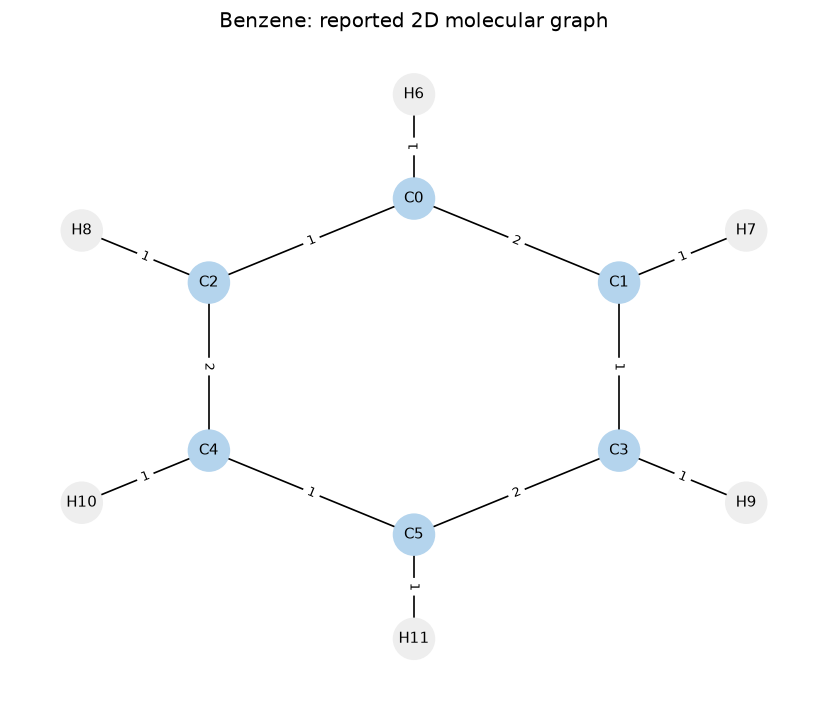

In [6]:
cid=241;record=parsed[cid];graph=graphs[cid]
positions={a["index"]:a["position"][:2] for a in record["atoms"]}
labels={a["index"]:a["element"]+str(a["index"]) for a in record["atoms"]}
fig,ax=plt.subplots(figsize=(7,6));nx.draw_networkx(graph,pos=positions,labels=labels,node_size=600,node_color=["#b4d4ed" if graph.nodes[j]["element"]=="C" else "#eeeeee" for j in graph],ax=ax,font_size=9)
nx.draw_networkx_edge_labels(graph,positions,edge_labels=nx.get_edge_attributes(graph,"reported_bond_type"),ax=ax,font_size=8)
ax.set_title("Benzene: reported 2D molecular graph");ax.axis("off");plt.tight_layout();plt.show()


### 3. Compare cyclomatic counts

For an undirected graph, cycle rank is edges−nodes+connected components. It counts independent graph cycles, not aromaticity or stereochemical rings. Explicit hydrogen nodes change degree counts but not this topological identity.

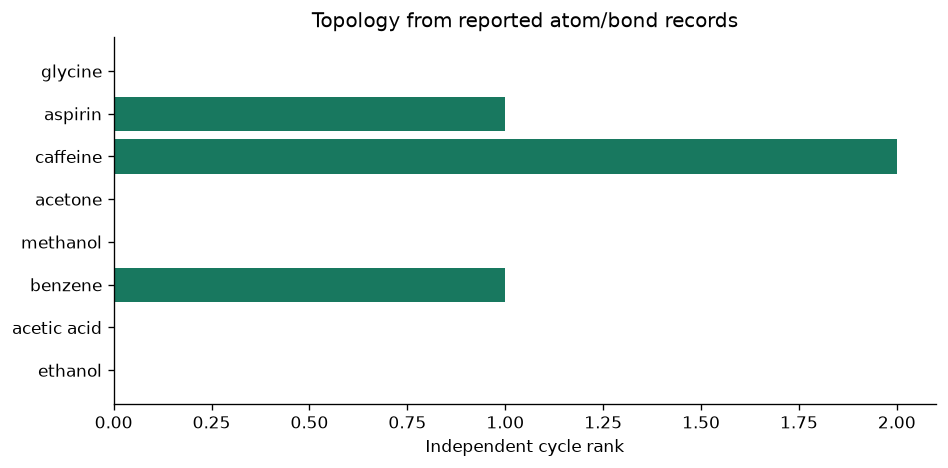

In [7]:
fig,ax=plt.subplots(figsize=(8,4));ax.barh(summary.name,summary.cycle_rank)
ax.set(xlabel="Independent cycle rank",title="Topology from reported atom/bond records");plt.tight_layout();plt.show()


### 4. Inspect node degrees

The histogram uses all atom nodes in the eight declared records, including explicit hydrogens. Graph degree counts neighbors; it differs from bond-order sum and chemical valence. This teaching parser does not implement a full chemistry toolkit.

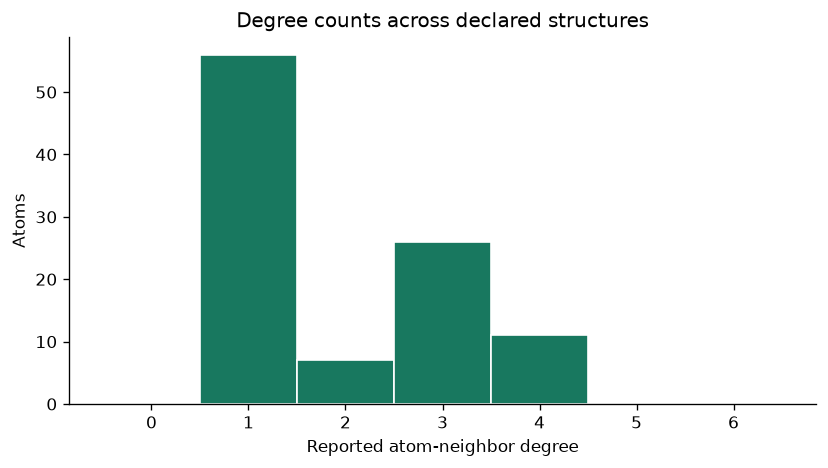

In [8]:
degrees=np.concatenate([np.array([degree for node,degree in graph.degree()]) for graph in graphs.values()])
fig,ax=plt.subplots(figsize=(7,4));ax.hist(degrees,bins=np.arange(-.5,6.6,1),edgecolor="white")
ax.set(xlabel="Reported atom-neighbor degree",ylabel="Atoms",title="Degree counts across declared structures");plt.tight_layout();plt.show()


### 5. Reconcile counts and export graph records

Check atom/bond counts against every source header and compare total formal charge with the property endpoint. Export one graph and the complete summary. Validation uses record identity; a visual drawing alone cannot establish parsing correctness.

In [9]:
for cid,record in parsed.items():
 assert graphs[cid].number_of_nodes()==record["atom_count"] and graphs[cid].number_of_edges()==record["bond_count"]
 assert summary.loc[cid,"formal_charge"]==properties.loc[cid,"Charge"]
assert summary.loc[241,"cycle_rank"]==1
OUTPUT_DIR.mkdir(parents=True,exist_ok=True);summary.to_csv(OUTPUT_DIR/"molecular-graph-summary.csv")
nx.write_graphml(graphs[241],OUTPUT_DIR/"benzene.graphml")
print("Header, graph and charge checks passed; exports:",OUTPUT_DIR)


Header, graph and charge checks passed; exports: /Users/zhiluo/Developer/vibeit-cookbook/cookbook/downloads/results/ch02-molecular-graphs


## Exercises and reference explanation

1. Distinguish degree, bond-type code and valence.
2. Explain cycle rank of benzene.

**Reference explanation.** Degree counts neighbors. A reported bond type is a source code, not an energy. A connected benzene graph has one independent topological cycle.

Keep a copy before changing parameters. Compare old and new figures and record which inputs, calculations and conclusions changed.

## Optional AI coding exercises

Open the current notebook in VibeIt's Coding Agent and ask it to read the relevant cells. The core lesson does not depend on AI access; see the Help Center for provider and account setup.

**Prompt 1**

> Using NumPy/Pandas/Matplotlib/NetworkX, draw another declared CID and retain source atom IDs and formal charges.

**Prompt 2**

> Using the same packages, export every declared graph to GraphML with only scalar attributes.

**Human acceptance.** Header counts, total charge and graph invariants reconcile; duplicate and self bonds are rejected.

Review the edited source, then manually run affected cells and subsequent checks. Ask the assistant to explain the purpose, packages and data provenance of its changes, and reconcile that explanation with actual output.

## Optional online extension

The network action below is disabled by default. It reports a database version/source without replacing the core data. To refresh data, save a separate experimental version and record the new URL, database release, retrieval date and SHA-256. New results require rerunning and validation.

In [10]:
RUN_ONLINE_UPDATE=False
if RUN_ONLINE_UPDATE:
    import requests
    try:
        response=requests.get('https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/2519/property/MolecularFormula/JSON',timeout=20)
        response.raise_for_status()
        print("Source:",response.url)
        print(response.text[:700])
    except requests.RequestException as error:
        print("Online extension unavailable:",type(error).__name__,str(error)[:160])
else:
    print("Online extension skipped; embedded core data unchanged")


Online extension skipped; embedded core data unchanged


## Sources, snapshots and next steps

- [PubChem calculated molecular properties](https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/702,176,241,887,180,2519,2244,750/property/MolecularFormula,MolecularWeight,HBondDonorCount,HBondAcceptorCount,HeavyAtomCount,XLogP,TPSA,Charge/JSON) — NCBI public data; PubChem computed properties only; credit PubChem; no third-party narrative annotations included; retrieved 2026-10-09. SHA-256 `b01b092cc8872e14fdab1fdc608c783669131a081c71d9ccee77c0bb9c6ff408`.
  Keep the returned calculated fields for eight declared CIDs; molecular weight converted from API numeric string.

- [PubChem 2D SDF 702](https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/702/SDF?record_type=2d) — NCBI public data; PubChem standardized structure; credit PubChem; retrieved 2026-10-09. SHA-256 `5962afc9ee8115dee9d5e63cefeef89cdc47641420b34afe156062d263c9caa7`.
  Preserve complete standardized SDF, including CID and explicit hydrogen/bond fields.

- [PubChem 2D SDF 176](https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/176/SDF?record_type=2d) — NCBI public data; PubChem standardized structure; credit PubChem; retrieved 2026-10-09. SHA-256 `f51353e1db0a0be8aa3aeb7bea28b6febb1e1f8afdf88fbf298405851f7ee092`.
  Preserve complete standardized SDF, including CID and explicit hydrogen/bond fields.

- [PubChem 2D SDF 241](https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/241/SDF?record_type=2d) — NCBI public data; PubChem standardized structure; credit PubChem; retrieved 2026-10-09. SHA-256 `3f4698bd6773f5e709184759048c116d106ac392e874676444b64af254e9a189`.
  Preserve complete standardized SDF, including CID and explicit hydrogen/bond fields.

- [PubChem 2D SDF 887](https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/887/SDF?record_type=2d) — NCBI public data; PubChem standardized structure; credit PubChem; retrieved 2026-10-09. SHA-256 `5cf6d180935f2fe77d20772a4bf2506711d4436762f6c6801157ac748f088530`.
  Preserve complete standardized SDF, including CID and explicit hydrogen/bond fields.

- [PubChem 2D SDF 180](https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/180/SDF?record_type=2d) — NCBI public data; PubChem standardized structure; credit PubChem; retrieved 2026-10-09. SHA-256 `6ecceacce326b6ecc292dedd946f589e879c999f43242395d995b59a8c8eb128`.
  Preserve complete standardized SDF, including CID and explicit hydrogen/bond fields.

- [PubChem 2D SDF 2519](https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/2519/SDF?record_type=2d) — NCBI public data; PubChem standardized structure; credit PubChem; retrieved 2026-10-09. SHA-256 `47293391d630f44f2a32c3f7702d766744c8f4a4f16f6571d4ae09f04b3daaed`.
  Preserve complete standardized SDF, including CID and explicit hydrogen/bond fields.

- [PubChem 2D SDF 2244](https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/2244/SDF?record_type=2d) — NCBI public data; PubChem standardized structure; credit PubChem; retrieved 2026-10-09. SHA-256 `0dfd04496745032c06410241f91f10fcec77cbc6828cdbede75f4c08da418fbb`.
  Preserve complete standardized SDF, including CID and explicit hydrogen/bond fields.

- [PubChem 2D SDF 750](https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/750/SDF?record_type=2d) — NCBI public data; PubChem standardized structure; credit PubChem; retrieved 2026-10-09. SHA-256 `e1c2ddd732cea1d052a9426c9a25fef86acd1309748bb2115cf2b56481ba288f`.
  Preserve complete standardized SDF, including CID and explicit hydrogen/bond fields.

- [PubChem caffeine 3D conformer](https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/2519/SDF?record_type=3d) — NCBI public data; PubChem computed conformer; credit PubChem; retrieved 2026-10-09. SHA-256 `2a78d98d09d50768fe3f6e6114d7baf3dad9cf88e41835735f96abf5867f5092`.
  Preserve calculated coordinates and conformer identifiers; not an experimental crystal structure.


**Next steps.** Transfer these methods to your own public or authorized data while retaining input checks, recorded parameters and result validation. Document the new experimental design and method limits; this example does not validate a new experiment. Full data licenses and generation instructions accompany the cookbook.